# Lab 6 — Метрики и валидация

1. Открываем валидационные данные
2. Восстанавливаем генератор из сохранённых весов (`models/generator.pth`)
3. Прогоняем предсказания на подвыборке и считаем метрики из `l5kit.evaluation`: ADE, FDE, RMSE и соревновательную NLL;
4. Сравниваем GAN vs VAE на тех же примерах.

In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision.models import resnet18

from l5kit.data import ChunkedDataset, LocalDataManager
from l5kit.dataset import AgentDataset
from l5kit.rasterization import build_rasterizer
from l5kit.geometry import transform_points
from l5kit.visualization import TARGET_POINTS_COLOR, PREDICTED_POINTS_COLOR, draw_trajectory

# метрики — официальные, из l5kit (те же, что использует evaluation-сервер соревнования)
from l5kit.evaluation.metrics import (
    neg_multi_log_likelihood,            # NLL — метрика соревнования
    average_displacement_error_oracle,   # ADE (лучшая из гипотез)
    final_displacement_error_oracle,     # FDE (лучшая из гипотез)
    average_displacement_error_mean,     # ADE (среднее по гипотезам)
    final_displacement_error_mean,       # FDE (среднее по гипотезам)
    rmse,
)

c:\Users\sadovets\Dev\BMSTU\IU1_ML\sem2\lab6\.venv\lib\site-packages\l5kit\dataset\select_agents.py:31: UserWarning: Windows detected. BLOSC_NOLOCK has not been set as it causes memory leaks on Windows.However, writing the mask with this config may be inconsistent.
  warnings.warn(


## 1. Данные

In [6]:
POS_SCALE = 50.0
FUTURE_FRAMES = 50

device = "cpu"
MODELS_DIR = Path("../models")

DATA_ROOT = Path("../data/raw").resolve()
FULL_DATA_ROOT = Path("D:/ML_datasets/lyft_data")

if (FULL_DATA_ROOT / "validate.zarr").exists():
    zarr_key, data_folder = "validate.zarr", FULL_DATA_ROOT
else:
    zarr_key, data_folder = "sample.zarr", DATA_ROOT
    print("validate.zarr не найден -> используем sample.zarr (демо-режим)")

os.environ["L5KIT_DATA_FOLDER"] = str(data_folder)


with open(Path("../models") / "cfg.json") as f:
    cfg = json.load(f)

In [ ]:
dm = LocalDataManager(None)
zarr_dataset = ChunkedDataset(dm.require(zarr_key)).open()
rasterizer = build_rasterizer(cfg, dm)
agent_dataset = AgentDataset(cfg, zarr_dataset, rasterizer)
print(f"Данные: {zarr_key}, примеров: {len(agent_dataset)}")

Данные: validate.zarr, примеров: 21624612


## 2. Импорт модели

In [4]:
class ImageEncoder(nn.Module):
    def __init__(self, in_channels, feat_dim=128):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, 5, 2, 2), nn.ReLU(),
            nn.Conv2d(32, 64, 5, 2, 2), nn.ReLU(),
            nn.Conv2d(64, 128, 5, 2, 2), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
        )
        self.fc = nn.Linear(128, feat_dim)

    def forward(self, x):
        return self.fc(self.conv(x))

class ResNetGenerator(nn.Module):
    def __init__(self, in_channels: int, future_frames: int = 50):
        super().__init__()
        backbone = resnet18(weights=None)
        backbone.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.backbone = backbone
        self.future_frames = future_frames
        self.head = nn.Linear(1000, future_frames * 2)

    def forward(self, image):
        return self.head(self.backbone(image)).view(-1, self.future_frames, 2)

class VAEGenerator(nn.Module):
    def __init__(self, in_channels, history_frames, future_frames, z_dim=16, feat_dim=128):
        super().__init__()
        self.z_dim = z_dim
        self.img_enc = ImageEncoder(in_channels, feat_dim)
        enc_in = (history_frames + future_frames) * 2
        self.enc = nn.Sequential(nn.Linear(enc_in, 256), nn.ReLU(),
                                 nn.Linear(256, 256), nn.ReLU())
        self.mu = nn.Linear(256, z_dim)
        self.logvar = nn.Linear(256, z_dim)
        dec_in = feat_dim + history_frames * 2 + z_dim
        self.dec = nn.Sequential(
            nn.Linear(dec_in, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, future_frames * 2),
        )
        self.future_frames = future_frames

    def encode(self, history, future):
        h = self.enc(torch.cat([history.flatten(1), future.flatten(1)], 1))
        return self.mu(h), self.logvar(h)

    def decode(self, image, history, z):
        x = torch.cat([self.img_enc(image), history.flatten(1), z], 1)
        return self.dec(x).view(-1, self.future_frames, 2)

    def forward(self, image, history, future=None):
        if future is not None:
            mu, logvar = self.encode(history, future)
            z = mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
            return self.decode(image, history, z), mu, logvar
        z = torch.randn(image.shape[0], self.z_dim, device=image.device)
        return self.decode(image, history, z)

In [7]:
gen_resnet = ResNetGenerator(in_channels=22).to(device)
gen_resnet.load_state_dict(torch.load(MODELS_DIR / "generator_resnet.pth", map_location=device))
gen_resnet.eval()
print("ResNetGenerator загружен")


gen_vae = VAEGenerator(22, 11, FUTURE_FRAMES).to(device)
gen_vae.load_state_dict(torch.load(MODELS_DIR / "generator_vae.pth", map_location=device))
gen_vae.eval()
print("VAEGenerator загружен")

ResNetGenerator загружен
VAEGenerator загружен


## 3. Предсказания на подвыборке

In [8]:
N_EVAL = 500   # число примеров; None = весь датасет

loader = DataLoader(agent_dataset, batch_size=16, shuffle=False)

def predict_all(model, loader, n_limit, is_vae=False):
    preds, gts, avails = [], [], []
    n_done = 0
    with torch.no_grad():
        for batch in loader:
            image = batch["image"].float().to(device)
            if is_vae:  # VAE на вход берёт ещё историю (и сэмплирует z)
                history = batch["history_positions"].float().to(device) / POS_SCALE
                out = model(image, history)
            else:
                out = model(image)
            preds.append(out.cpu().numpy() * POS_SCALE)  # обратно в метры
            gts.append(batch["target_positions"].numpy())
            avails.append(batch["target_availabilities"].numpy())
            n_done += len(image)
            if n_limit is not None and n_done >= n_limit:
                break
    n = n_done if n_limit is None else min(n_done, n_limit)
    return (np.concatenate(gts)[:n], np.concatenate(preds)[:n],
            np.concatenate(avails)[:n])

In [ ]:
gt, pred_resnet, avail = predict_all(gen_resnet, loader, N_EVAL)
print(f"Оценено примеров: {len(gt)}")

_, pred_vae, _ = predict_all(gen_vae, loader, N_EVAL, is_vae=True)
print("Предсказания VAE готовы")

Оценено примеров: 500
Предсказания VAE готовы (на тех же примерах, тот же порядок)


## 4. Метрики

Все функции из `l5kit.evaluation.metrics` принимают **один** пример:
`ground_truth (50, 2)`, `pred (M, 50, 2)`, `confidences (M,)`, `avails (50,)`
и возвращают одно число — поэтому считаем в цикле и усредняем.

- **ADE** (average displacement error) — средняя ошибка по всем 50 точкам, м:
  `mean_t ||pred_t - gt_t||`;
- **FDE** (final displacement error) — ошибка в последней точке, м (куда приехали через 5 с);
- **RMSE** — корень из среднего квадрата ошибки, м;
- **NLL** — метрика соревнования: отрицательный логарифм правдоподобия GT под
  гауссианой вокруг предсказанной траектории.

`_oracle` = лучшая из гипотез, `_mean` = среднее по гипотезам.

In [10]:
def evaluate(gt, pred, avail):
    # Считает метрики l5kit по всем примерам. pred: (N, 50, 2) — одна гипотеза.
    rows = {"NLL": [], "ADE": [], "FDE": [], "ADE_mean": [], "FDE_mean": [], "RMSE": []}
    for i in range(len(gt)):
        p = pred[i][None]                    # (1, 50, 2) — одна гипотеза
        c = np.ones(1, dtype=np.float32)     # уверенность 100% в единственной гипотезе
        rows["NLL"].append(neg_multi_log_likelihood(gt[i], p, c, avail[i]))
        rows["ADE"].append(average_displacement_error_oracle(gt[i], p, c, avail[i]))
        rows["FDE"].append(final_displacement_error_oracle(gt[i], p, c, avail[i]))
        rows["ADE_mean"].append(average_displacement_error_mean(gt[i], p, c, avail[i]))
        rows["FDE_mean"].append(final_displacement_error_mean(gt[i], p, c, avail[i]))
        rows["RMSE"].append(rmse(gt[i], p, c, avail[i]))
    return {k: np.array(v) for k, v in rows.items()}


def show_metrics(name, m):
    print(f"--- {name} ---")
    print(f"  NLL  (метрика соревнования): {m['NLL'].mean():9.3f}")
    print(f"  ADE  (средняя ошибка, м):    {m['ADE'].mean():9.3f}")
    print(f"  FDE  (ошибка в конце, м):    {m['FDE'].mean():9.3f}")
    print(f"  RMSE (м):                    {m['RMSE'].mean():9.3f}")

--- GAN (ResNet-18 генератор) ---
  NLL  (метрика соревнования):  1697.430
  ADE  (средняя ошибка, м):        3.795
  FDE  (ошибка в конце, м):        8.148
  RMSE (м):                        4.784


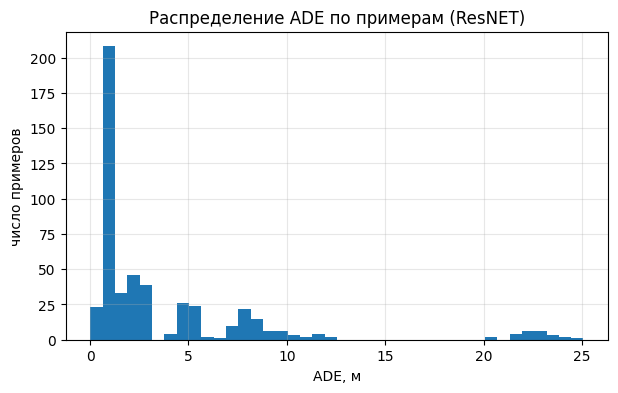

In [15]:
metrics_resnet = evaluate(gt, pred_resnet, avail)
show_metrics("GAN (ResNet-18 генератор)", metrics_resnet)

plt.figure(figsize=(7, 4))
plt.hist(metrics_resnet["ADE"], bins=40)
plt.xlabel("ADE, м")
plt.ylabel("число примеров")
plt.title("Распределение ADE по примерам (ResNET)")
plt.grid(alpha=0.3)
plt.show()

--- GAN (ResNet-18 генератор) ---
  NLL  (метрика соревнования):   674.715
  ADE  (средняя ошибка, м):        2.498
  FDE  (ошибка в конце, м):        5.906
  RMSE (м):                        3.163


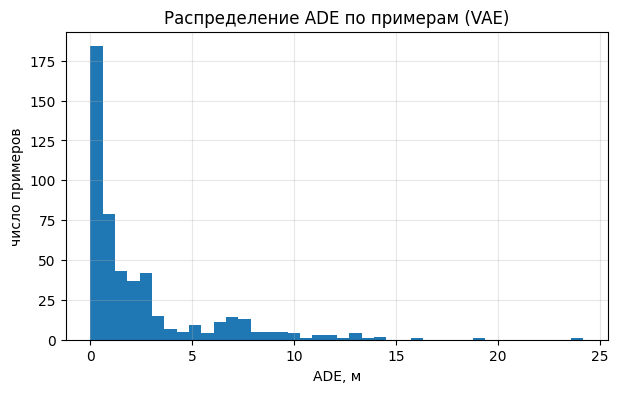

In [14]:
metrics_vae = evaluate(gt, pred_vae, avail)
show_metrics("GAN (ResNet-18 генератор)", metrics_vae)

plt.figure(figsize=(7, 4))
plt.hist(metrics_vae["ADE"], bins=40)
plt.xlabel("ADE, м")
plt.ylabel("число примеров")
plt.title("Распределение ADE по примерам (VAE)")
plt.grid(alpha=0.3)
plt.show()

## 5. Сравнение: GAN vs VAE-генератор

In [ ]:
class ImageEncoder(nn.Module):
    # Лёгкий CNN-энкодер растра -> вектор признаков
    def __init__(self, in_channels, feat_dim=128):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, 5, 2, 2), nn.ReLU(),
            nn.Conv2d(32, 64, 5, 2, 2), nn.ReLU(),
            nn.Conv2d(64, 128, 5, 2, 2), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
        )
        self.fc = nn.Linear(128, feat_dim)

    def forward(self, x):
        return self.fc(self.conv(x))


class VAEGenerator(nn.Module):
    def __init__(self, in_channels, history_frames, future_frames, z_dim=16, feat_dim=128):
        super().__init__()
        self.z_dim = z_dim
        self.img_enc = ImageEncoder(in_channels, feat_dim)
        enc_in = (history_frames + future_frames) * 2
        self.enc = nn.Sequential(nn.Linear(enc_in, 256), nn.ReLU(), nn.Linear(256, 256), nn.ReLU())
        self.mu = nn.Linear(256, z_dim)
        self.logvar = nn.Linear(256, z_dim)
        dec_in = feat_dim + history_frames * 2 + z_dim
        self.dec = nn.Sequential(
            nn.Linear(dec_in, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, future_frames * 2),
        )
        self.future_frames = future_frames

    def encode(self, history, future):
        h = self.enc(torch.cat([history.flatten(1), future.flatten(1)], 1))
        return self.mu(h), self.logvar(h)

    def decode(self, image, history, z):
        x = torch.cat([self.img_enc(image), history.flatten(1), z], 1)
        return self.dec(x).view(-1, self.future_frames, 2)

    def forward(self, image, history, future=None):
        if future is not None:   # режим обучения: z из энкодера
            mu, logvar = self.encode(history, future)
            z = mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
            return self.decode(image, history, z), mu, logvar
        # режим предсказания: z ~ N(0, 1)
        z = torch.randn(image.shape[0], self.z_dim, device=image.device)
        return self.decode(image, history, z)

models/vae_generator.pth не найден — сначала обучи VAE-генератор в ноутбуке 02.


In [20]:
vae_path = Path("../models") / "generator_vae.pth"

V = VAEGenerator(22, 11, FUTURE_FRAMES).to(device)
V.load_state_dict(torch.load(vae_path, map_location=device))
V.eval()

print(f"{'метрика':<10}{'ResNet':>12}{'VAE':>12}")
for k in ["NLL", "ADE", "FDE", "RMSE"]:
    print(f"{k:<10}{metrics_resnet[k].mean():>12.3f}{metrics_vae[k].mean():>12.3f}")

метрика         ResNet         VAE
NLL           1697.430     575.550
ADE              3.795       2.402
FDE              8.148       5.739
RMSE             4.784       3.054


## 6. Визуализация: лучший и худший пример

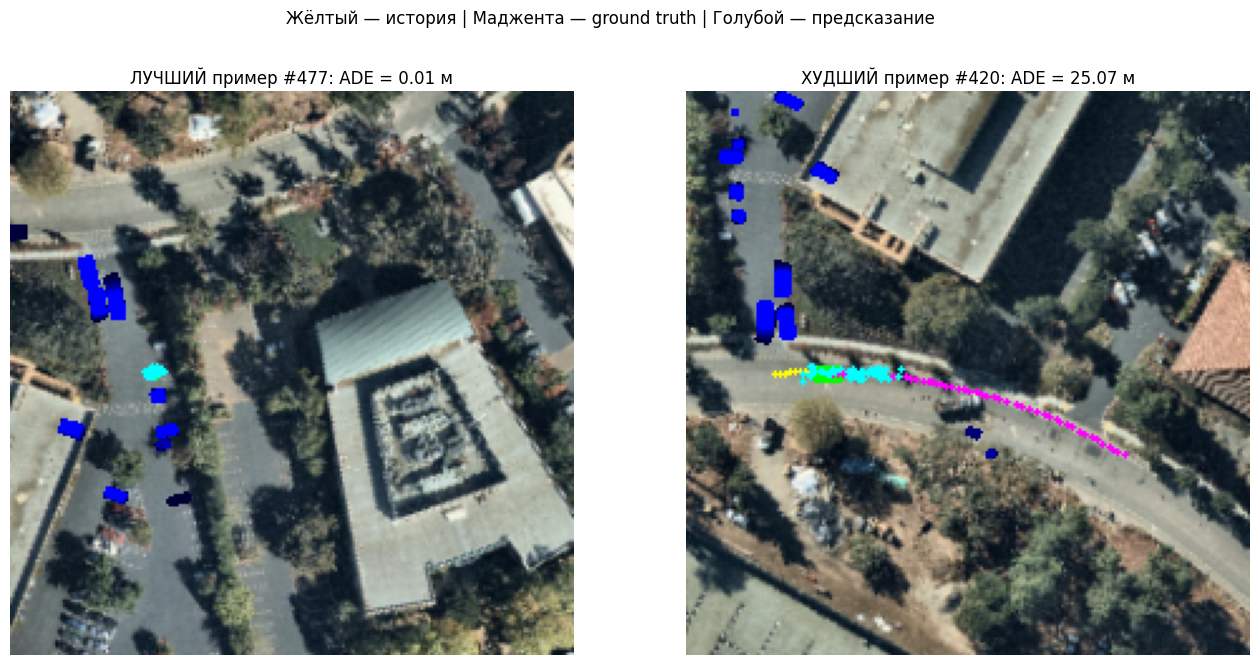

In [23]:
idx_best = int(metrics_resnet["ADE"].argmin())
idx_worst = int(metrics_resnet["ADE"].argmax())

try:
    cfg_sat = {**cfg, "raster_params": {**cfg["raster_params"],
               "map_type": "py_satellite",
               "satellite_map_key": "aerial_map/aerial_map.png",
               "semantic_map_key": "semantic_map/semantic_map.pb"}
               }
    
    rasterizer_viz = build_rasterizer(cfg_sat, dm)
    viz_dataset = AgentDataset(cfg_sat, zarr_dataset, rasterizer_viz)
    _ = viz_dataset[0]  
except Exception as e:
    print(f"Спутник недоступен ({type(e).__name__}) -> рисуем на box_debug")
    rasterizer_viz, viz_dataset = rasterizer, agent_dataset


fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, idx, tag in [(axes[0], idx_best, "ЛУЧШИЙ"), (axes[1], idx_worst, "ХУДШИЙ")]:
    data = viz_dataset[idx]
    im = rasterizer_viz.to_rgb(data["image"].transpose(1, 2, 0))
    m = data["raster_from_agent"]
    draw_trajectory(im, transform_points(data["history_positions"], m), (255, 255, 0))
    draw_trajectory(im, transform_points(data["target_positions"], m), TARGET_POINTS_COLOR)
    draw_trajectory(im, transform_points(pred_resnet[idx], m), PREDICTED_POINTS_COLOR)
    
    ax.imshow(im)
    ax.set_title(f"{tag} пример #{idx}: ADE = {metrics_resnet['ADE'][idx]:.2f} м")
    ax.axis("off")
    

fig.suptitle("Жёлтый — история | Маджента — ground truth | Голубой — предсказание", y=0.95)
plt.show()